# HR PEOPLE ANALYTICS — Partie 4 : Fairness & Équité

Objectif : Détecter les biais algorithmiques et structurels dans les données RH — genre, âge, origine ethnique.

Méthodes : Disparate Impact, Statistical Parity, Demographic Parity, tests statistiques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
import warnings
warnings.filterwarnings("ignore")

# ── Style global ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3d4d",   "axes.labelcolor": "#e0e0e0",
    "xtick.color": "#a0a0b0",      "ytick.color": "#a0a0b0",
    "text.color": "#e0e0e0",       "grid.color": "#2a2d3d",
    "grid.linestyle": "--",        "grid.alpha": 0.5,
})
ACCENT, WARN, OK = "#4f8ef7", "#f7794f", "#4ff7a0"
PALETTE = ["#4f8ef7", "#f7794f", "#4ff7a0", "#f7d44f", "#c44ff7", "#f74fa0"]

## Chargement des datasets

In [2]:
master   = pd.read_csv("master_hr_anomalies.csv")
recruit  = pd.read_csv("recruitment_data.csv")
training = pd.read_csv("training_and_development_data.csv")

# Reconstruction des colonnes démographiques depuis one-hot
gender_cols = [c for c in master.columns if c.startswith("GenderCode_")]
race_cols   = [c for c in master.columns if c.startswith("RaceDesc_")]

master["Gender"] = master[gender_cols].idxmax(axis=1).str.replace("GenderCode_", "")
master["Race"]   = master[race_cols].idxmax(axis=1).str.replace("RaceDesc_", "")

print(f"Master chargé : {master.shape}")
print(f"   Genres   : {master['Gender'].value_counts().to_dict()}")
print(f"   Ethnies  : {master['Race'].value_counts().to_dict()}")

Master chargé : (3000, 84)
   Genres   : {'Female': 1682, 'Male': 1318}
   Ethnies  : {'Asian': 629, 'Black': 618, 'White': 599, 'Other': 582, 'Hispanic': 572}


## HELPER - Disparate Impact Ratio

In [4]:
def disparate_impact(df, group_col, outcome_col, privileged_group, threshold=0.8):
    """
    Calcule le Disparate Impact Ratio (DIR).
    DIR = P(outcome | unprivileged) / P(outcome | privileged)
    DIR < 0.8 → discrimination potentielle (règle des 4/5)
    """
    results = []
    priv_rate = df[df[group_col] == privileged_group][outcome_col].mean()
    for group in df[group_col].unique():
        if group == privileged_group:
            continue
        group_rate = df[df[group_col] == group][outcome_col].mean()
        dir_ratio  = group_rate / priv_rate if priv_rate > 0 else np.nan
        results.append({
            "Group":           group,
            "Rate":            round(group_rate, 3),
            "Privileged_Rate": round(priv_rate, 3),
            "DIR":             round(dir_ratio, 3),
            "Biased":          dir_ratio < threshold if pd.notna(dir_ratio) else False
        })
    return pd.DataFrame(results)


def statistical_parity_diff(df, group_col, outcome_col, privileged_group):
    """
    Statistical Parity Difference = P(outcome|unprivileged) - P(outcome|privileged)
    Idéalement = 0. Négatif = désavantage pour le groupe non-privilégié.
    """
    priv_rate = df[df[group_col] == privileged_group][outcome_col].mean()
    results   = []
    for group in df[group_col].unique():
        if group == privileged_group:
            continue
        group_rate = df[df[group_col] == group][outcome_col].mean()
        results.append({
            "Group": group,
            "SPD":   round(group_rate - priv_rate, 3),
            "Biased": abs(group_rate - priv_rate) > 0.1
        })
    return pd.DataFrame(results)

## Fairness - Performance et Promotions

In [5]:
print("\nAnalyse Fairness — Performance...")

# Variable binaire : "Exceeds" = haute performance
master["High_Perf"] = (master["Performance Score"] == "Exceeds").astype(int)

# DIR par genre
dir_gender_perf = disparate_impact(master, "Gender", "High_Perf", "Male")
print(f"\n  DIR Performance par Genre :")
print(dir_gender_perf.to_string(index=False))

# DIR par ethnie
dir_race_perf = disparate_impact(master, "Race", "High_Perf", "White")
print(f"\n  DIR Performance par Ethnie :")
print(dir_race_perf.to_string(index=False))

# Test Mann-Whitney U — performance score numérique vs genre
male_perf   = master[master["Gender"] == "Male"]["Performance_Num"].dropna()
female_perf = master[master["Gender"] == "Female"]["Performance_Num"].dropna()
u_stat, p_val = mannwhitneyu(male_perf, female_perf, alternative="two-sided")
print(f"\n  Mann-Whitney U (Perf ~ Genre) : U={u_stat:.0f}, p={p_val:.4f}")
print(f"  → {'⚠️  Différence significative' if p_val < 0.05 else '✅ Pas de différence significative'}")


Analyse Fairness — Performance...

  DIR Performance par Genre :
 Group  Rate  Privileged_Rate   DIR  Biased
Female 0.144            0.096 1.511   False

  DIR Performance par Ethnie :
   Group  Rate  Privileged_Rate   DIR  Biased
Hispanic 0.131            0.132 0.994   False
   Other 0.132            0.132 1.003   False
   Black 0.094            0.132 0.712    True
   Asian 0.127            0.132 0.964   False

  Mann-Whitney U (Perf ~ Genre) : U=1072006, p=0.0303
  → ⚠️  Différence significative


## Fairness - Engagement & Satisfaction

In [6]:
print("\nAnalyse Fairness — Engagement...")

# SPD engagement par genre
spd_gender_eng = statistical_parity_diff(master, "Gender", "Engagement_Composite", "Male")
print(f"\n  SPD Engagement par Genre :\n{spd_gender_eng.to_string(index=False)}")

# Kruskal-Wallis — engagement par ethnie (test non-paramétrique multi-groupes)
groups_eng = [master[master["Race"] == r]["Engagement_Composite"].dropna()
              for r in master["Race"].unique()]
h_stat, p_kruskal = kruskal(*groups_eng)
print(f"\n  Kruskal-Wallis (Engagement ~ Ethnie) : H={h_stat:.2f}, p={p_kruskal:.4f}")
print(f"  → {'⚠️  Différence significative entre ethnies' if p_kruskal < 0.05 else '✅ Pas de différence significative'}")


Analyse Fairness — Engagement...

  SPD Engagement par Genre :
 Group    SPD  Biased
Female -0.015   False

  Kruskal-Wallis (Engagement ~ Ethnie) : H=2.93, p=0.5691
  → ✅ Pas de différence significative


In [7]:
## Fairness - Accès à la formation
print("\nAnalyse Fairness — Accès à la Formation...")

# Taux de réussite formation par genre
master["Training_Success"] = (master["Training_Pass_Rate"] >= 0.5).astype(int)
dir_gender_train = disparate_impact(master, "Gender", "Training_Success", "Male")
print(f"\n  DIR Réussite Formation par Genre :\n{dir_gender_train.to_string(index=False)}")

# Chi2 — réussite formation vs genre
ct = pd.crosstab(master["Gender"], master["Training_Success"])
chi2, p_chi2, dof, _ = chi2_contingency(ct)
print(f"\n  Chi² (Formation ~ Genre) : χ²={chi2:.2f}, p={p_chi2:.4f}, dof={dof}")
print(f"  → {'⚠️  Association significative' if p_chi2 < 0.05 else '✅ Pas d association significative'}")


Analyse Fairness — Accès à la Formation...

  DIR Réussite Formation par Genre :
 Group  Rate  Privileged_Rate   DIR  Biased
Female 0.249            0.243 1.026   False

  Chi² (Formation ~ Genre) : χ²=0.13, p=0.7220, dof=1
  → ✅ Pas d association significative


In [9]:
## Fairness - Recrutement
print("\nAnalyse Fairness — Recrutement...")

recruit["Hired"] = (recruit["Status"] == "Hired").astype(int)

# DIR embauche par genre
dir_gender_hire = disparate_impact(recruit, "Gender", "Hired", "Male")
print(f"\n  DIR Embauche par Genre :\n{dir_gender_hire.to_string(index=False)}")

# Salaire désiré par genre — test Mann-Whitney
male_sal   = recruit[recruit["Gender"] == "Male"]["Desired Salary"].dropna()
female_sal = recruit[recruit["Gender"] == "Female"]["Desired Salary"].dropna()
u2, p2     = mannwhitneyu(male_sal, female_sal, alternative="two-sided")
print(f"\n  Mann-Whitney U (Salaire désiré ~ Genre) : U={u2:.0f}, p={p2:.4f}")
print(f"  → {'⚠️  Écart salarial significatif' if p2 < 0.05 else '✅ Pas d\'écart significatif'}")


Analyse Fairness — Recrutement...

  DIR Embauche par Genre :
 Group  Rate  Privileged_Rate  DIR  Biased
Female   0.0              0.0  NaN   False
 Other   0.0              0.0  NaN   False

  Mann-Whitney U (Salaire désiré ~ Genre) : U=503355, p=0.6778
  → ✅ Pas d'écart significatif


## Fairness - Attrition par groupe

In [10]:
print("\nAnalyse Fairness — Attrition...")

master["Attrition"] = (~master["Is_Active"].astype(bool)).astype(int)

dir_gender_attr = disparate_impact(master, "Gender", "Attrition", "Male")
dir_race_attr   = disparate_impact(master, "Race",   "Attrition", "White")
print(f"\n  DIR Attrition par Genre :\n{dir_gender_attr.to_string(index=False)}")
print(f"\n  DIR Attrition par Ethnie :\n{dir_race_attr.to_string(index=False)}")


Analyse Fairness — Attrition...

  DIR Attrition par Genre :
 Group  Rate  Privileged_Rate   DIR  Biased
Female 0.514            0.507 1.015   False

  DIR Attrition par Ethnie :
   Group  Rate  Privileged_Rate   DIR  Biased
Hispanic 0.510            0.499 1.023   False
   Other 0.512            0.499 1.026   False
   Black 0.503            0.499 1.008   False
   Asian 0.529            0.499 1.061   False


## Visualisations


Génération des visualisations Fairness...


Text(0.5, 0.98, 'HR People Analytics — Fairness & Équité Algorithmique')

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


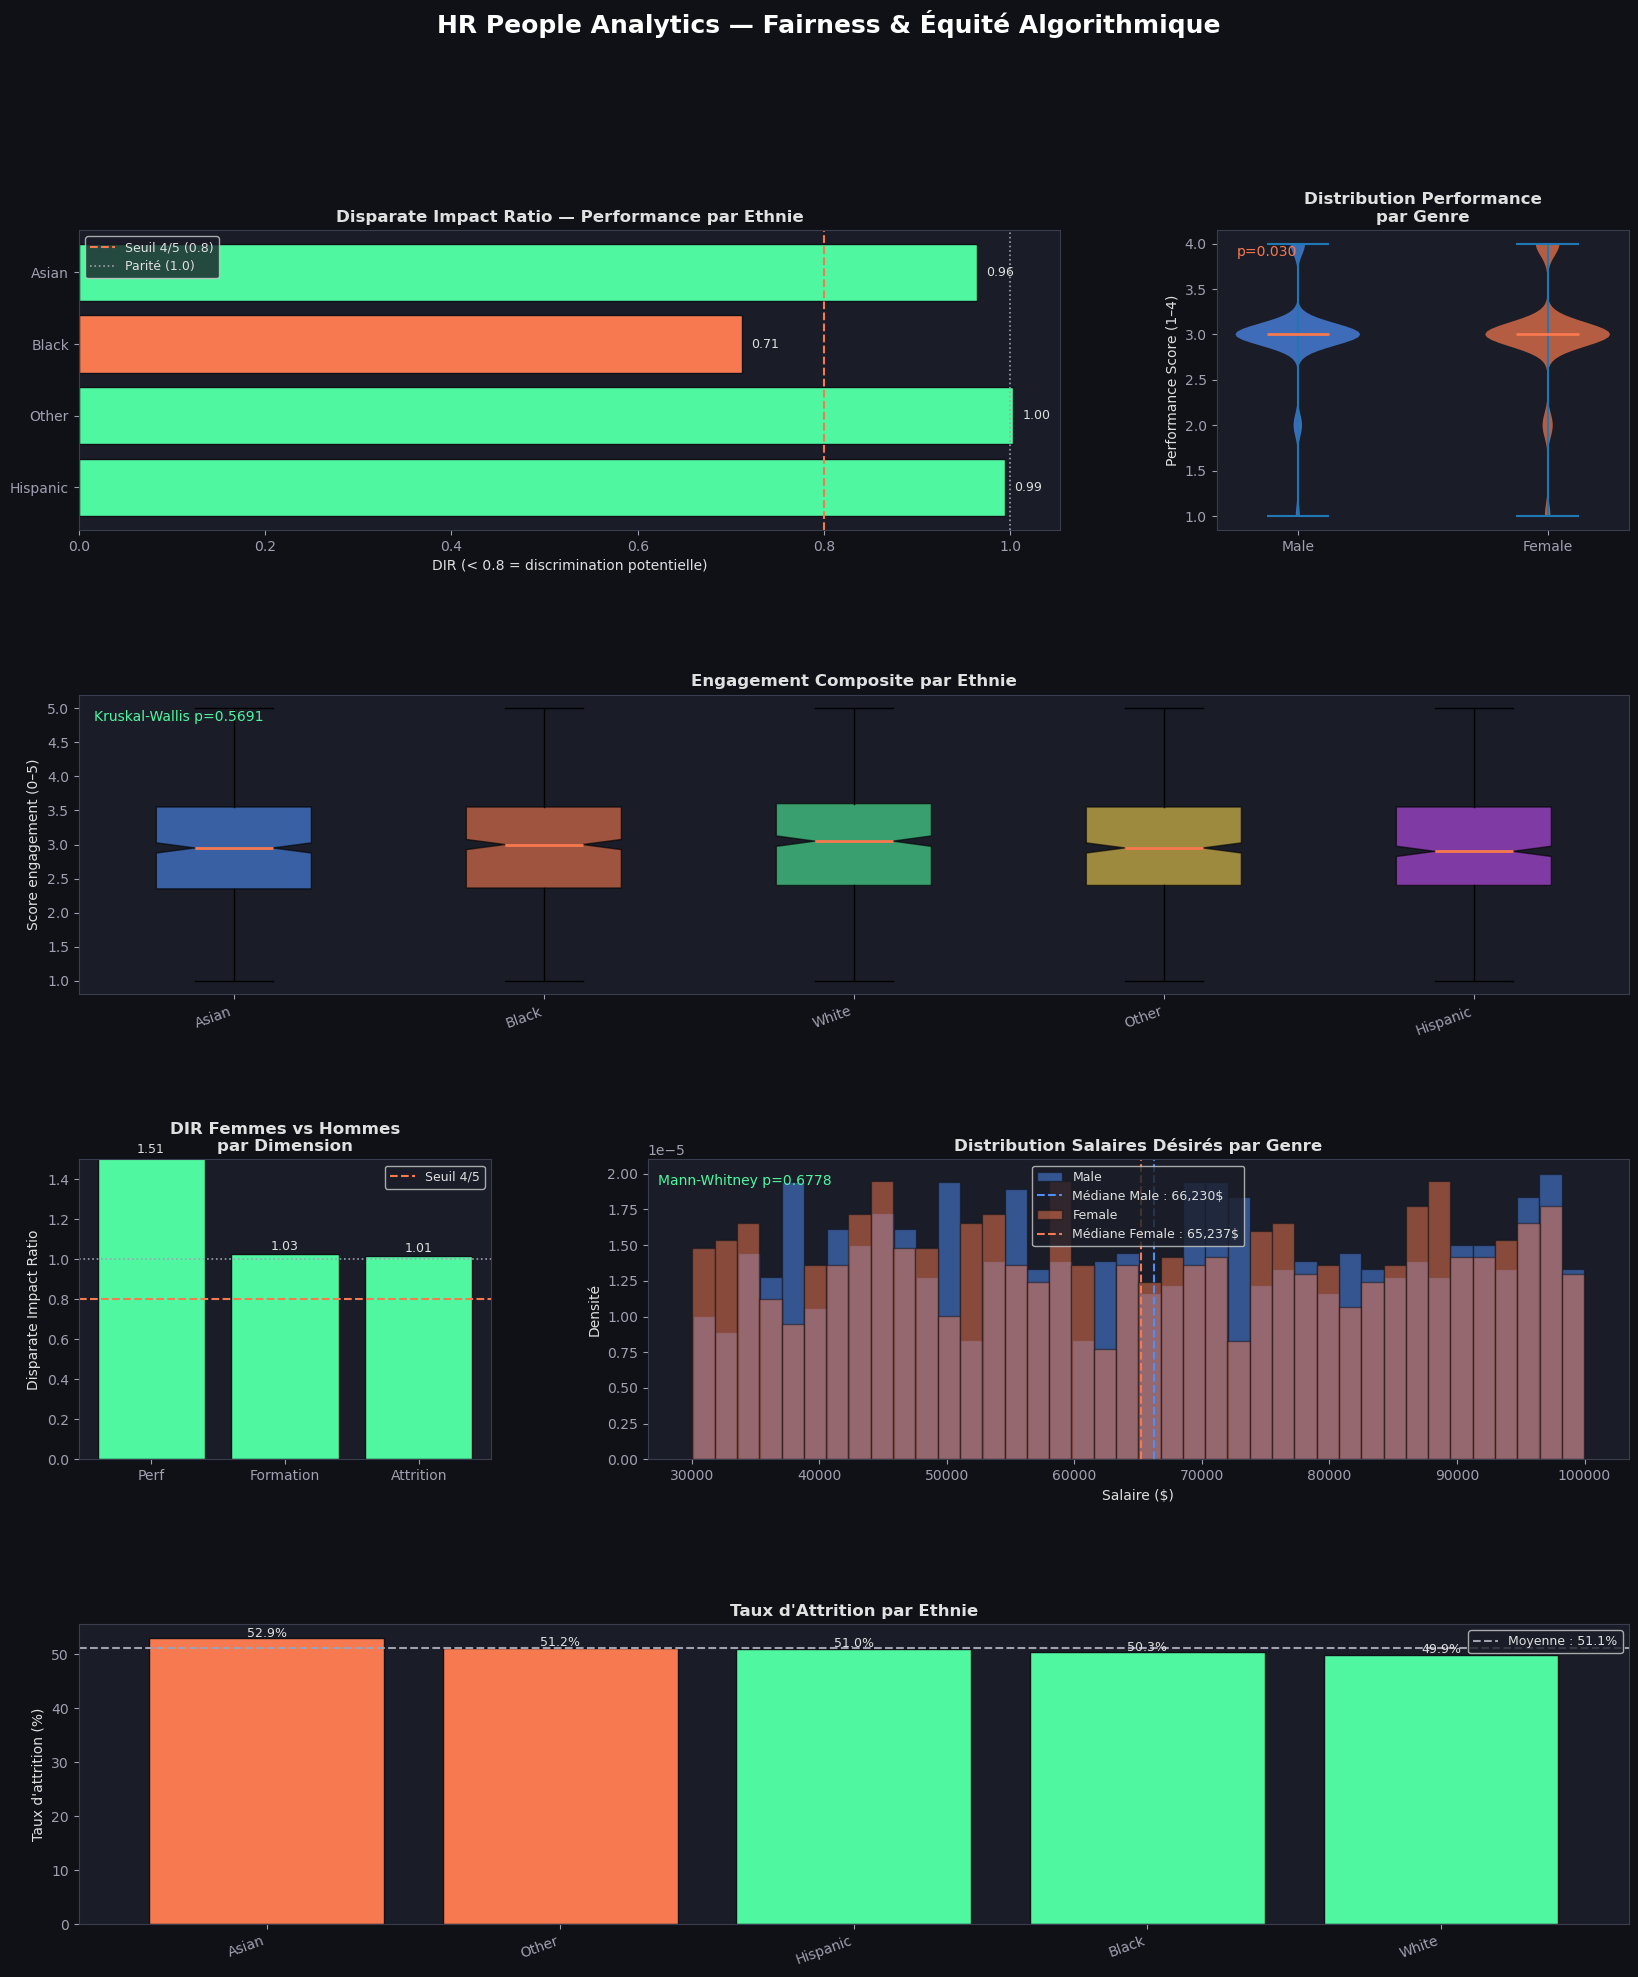

In [ ]:
print("\nGénération des visualisations Fairness...")

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)


# 8.1 DIR Performance par Ethnie
ax1 = fig.add_subplot(gs[0, :2])
colors1 = [WARN if b else OK for b in dir_race_perf["Biased"]]
bars1   = ax1.barh(dir_race_perf["Group"], dir_race_perf["DIR"],
                   color=colors1, edgecolor="#0f1117")
ax1.axvline(0.8, color=WARN, linestyle="--", linewidth=1.5, label="Seuil 4/5 (0.8)")
ax1.axvline(1.0, color="#a0a0b0", linestyle=":", linewidth=1.2, label="Parité (1.0)")
ax1.set_title("Disparate Impact Ratio — Performance par Ethnie", fontsize=12, fontweight="bold")
ax1.set_xlabel("DIR (< 0.8 = discrimination potentielle)")
ax1.legend(fontsize=9)
for bar in bars1:
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.2f}", va="center", fontsize=9)


# 8.2 Performance par genre — violin
ax2 = fig.add_subplot(gs[0, 2])
perf_gender = [master[master["Gender"] == g]["Performance_Num"].dropna()
               for g in ["Male", "Female"]]
vp = ax2.violinplot(perf_gender, positions=[1, 2], showmedians=True, showextrema=True)
for i, pc in enumerate(vp["bodies"]):
    pc.set_facecolor(PALETTE[i]); pc.set_alpha(0.7)
vp["cmedians"].set_color(WARN); vp["cmedians"].set_linewidth(2)
ax2.set_xticks([1, 2]); ax2.set_xticklabels(["Male", "Female"])
ax2.set_title("Distribution Performance\npar Genre", fontsize=12, fontweight="bold")
ax2.set_ylabel("Performance Score (1–4)")
ax2.text(0.05, 0.95, f"p={p_val:.3f}", transform=ax2.transAxes,
         color=WARN if p_val < 0.05 else OK, fontsize=10, va="top")


# 8.3 Engagement par ethnie — boxplot
ax3 = fig.add_subplot(gs[1, :])
races = master["Race"].value_counts().index.tolist()
bp_data3 = [master[master["Race"] == r]["Engagement_Composite"].dropna() for r in races]
bp3 = ax3.boxplot(bp_data3, labels=races, patch_artist=True, notch=True,
                  medianprops=dict(color=WARN, linewidth=2),
                  flierprops=dict(marker="o", alpha=0.3, markersize=3))
for patch, c in zip(bp3["boxes"], PALETTE * 3):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax3.set_title("Engagement Composite par Ethnie", fontsize=12, fontweight="bold")
ax3.set_ylabel("Score engagement (0–5)")
ax3.text(0.01, 0.95, f"Kruskal-Wallis p={p_kruskal:.4f}",
         transform=ax3.transAxes,
         color=WARN if p_kruskal < 0.05 else OK, fontsize=10, va="top")
plt.setp(ax3.get_xticklabels(), rotation=20, ha="right")


# 8.4 DIR Recrutement par genre
ax4 = fig.add_subplot(gs[2, 0])
metrics = ["Embauche", "Perf", "Formation", "Attrition"]
dir_vals = [
    dir_gender_hire["DIR"].values[0]  if len(dir_gender_hire) > 0  else 1,
    dir_gender_perf["DIR"].values[0]  if len(dir_gender_perf) > 0  else 1,
    dir_gender_train["DIR"].values[0] if len(dir_gender_train) > 0 else 1,
    dir_gender_attr["DIR"].values[0]  if len(dir_gender_attr) > 0  else 1,
]
colors4 = [WARN if v < 0.8 else OK for v in dir_vals]
bars4   = ax4.bar(metrics, dir_vals, color=colors4, edgecolor="#0f1117")
ax4.axhline(0.8, color=WARN, linestyle="--", linewidth=1.5, label="Seuil 4/5")
ax4.axhline(1.0, color="#a0a0b0", linestyle=":", linewidth=1.2)
ax4.set_title("DIR Femmes vs Hommes\npar Dimension", fontsize=12, fontweight="bold")
ax4.set_ylabel("Disparate Impact Ratio")
ax4.set_ylim(0, 1.5)
ax4.legend(fontsize=9)
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha="center", fontsize=9)


# 8.5 Salaire désiré par genre — densité
ax5 = fig.add_subplot(gs[2, 1:])
for i, (gender, color) in enumerate(zip(["Male", "Female"], [ACCENT, WARN])):
    data = recruit[recruit["Gender"] == gender]["Desired Salary"].dropna()
    ax5.hist(data, bins=40, alpha=0.5, color=color, label=gender,
             density=True, edgecolor="#0f1117")
    ax5.axvline(data.median(), color=color, linestyle="--", linewidth=1.5,
                label=f"Médiane {gender} : {data.median():,.0f}$")
ax5.set_title("Distribution Salaires Désirés par Genre", fontsize=12, fontweight="bold")
ax5.set_xlabel("Salaire ($)"); ax5.set_ylabel("Densité")
ax5.text(0.01, 0.95, f"Mann-Whitney p={p2:.4f}",
         transform=ax5.transAxes,
         color=WARN if p2 < 0.05 else OK, fontsize=10, va="top")
ax5.legend(fontsize=9)


# 8.6 Taux attrition par ethnie
ax6 = fig.add_subplot(gs[3, :])
attr_race = master.groupby("Race")["Attrition"].mean().sort_values(ascending=False) * 100
colors6   = [WARN if v > attr_race.mean() else OK for v in attr_race.values]
bars6     = ax6.bar(attr_race.index, attr_race.values, color=colors6, edgecolor="#0f1117")
ax6.axhline(attr_race.mean(), color="#a0a0b0", linestyle="--", linewidth=1.5,
            label=f"Moyenne : {attr_race.mean():.1f}%")
ax6.set_title("Taux d'Attrition par Ethnie", fontsize=12, fontweight="bold")
ax6.set_ylabel("Taux d'attrition (%)")
ax6.legend(fontsize=9)
plt.setp(ax6.get_xticklabels(), rotation=20, ha="right")
for bar in bars6:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", fontsize=9)


# ── Titre ─────────────────────────────────────────────────────
fig.suptitle("HR People Analytics — Fairness & Équité Algorithmique",
             fontsize=18, fontweight="bold", color="white", y=0.98)

# plt.savefig("04_fairness.png", dpi=150, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
# plt.close()
# print("Sauvegardé : 04_fairness.png")

## Rapport Fairness Consolidé

In [13]:
print("\n" + "="*60)
print("RAPPORT FAIRNESS CONSOLIDÉ")
print("="*60)

checks = [
    ("Performance ~ Genre",    p_val,     "Mann-Whitney U"),
    ("Engagement ~ Ethnie",    p_kruskal, "Kruskal-Wallis"),
    ("Formation ~ Genre",      p_chi2,    "Chi²"),
    ("Salaire désiré ~ Genre", p2,        "Mann-Whitney U"),
]
for label, p, test in checks:
    status = "⚠️  BIAIS DÉTECTÉ" if p < 0.05 else "✅ Équitable"
    print(f"  {label:<30} [{test}]  p={p:.4f}  →  {status}")

print("\n  Disparate Impact Ratio (règle des 4/5) :")
all_dirs = [
    ("Perf ~ Ethnie",     dir_race_perf),
    ("Perf ~ Genre",      dir_gender_perf),
    ("Embauche ~ Genre",  dir_gender_hire),
    ("Formation ~ Genre", dir_gender_train),
    ("Attrition ~ Genre", dir_gender_attr),
    ("Attrition ~ Ethnie",dir_race_attr),
]
for label, df_dir in all_dirs:
    if len(df_dir) > 0:
        biased = df_dir[df_dir["Biased"]]["Group"].tolist()
        status = f"⚠️  {biased}" if biased else "✅ OK"
        print(f"  {label:<25} → {status}")

print("="*60)

master.to_csv("master_hr_fairness.csv", index=False)
print("\nmaster_hr_fairness.csv exporté")


RAPPORT FAIRNESS CONSOLIDÉ
  Performance ~ Genre            [Mann-Whitney U]  p=0.0303  →  ⚠️  BIAIS DÉTECTÉ
  Engagement ~ Ethnie            [Kruskal-Wallis]  p=0.5691  →  ✅ Équitable
  Formation ~ Genre              [Chi²]  p=0.7220  →  ✅ Équitable
  Salaire désiré ~ Genre         [Mann-Whitney U]  p=0.6778  →  ✅ Équitable

  Disparate Impact Ratio (règle des 4/5) :
  Perf ~ Ethnie             → ⚠️  ['Black']
  Perf ~ Genre              → ✅ OK
  Embauche ~ Genre          → ✅ OK
  Formation ~ Genre         → ✅ OK
  Attrition ~ Genre         → ✅ OK
  Attrition ~ Ethnie        → ✅ OK

master_hr_fairness.csv exporté
